In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
x = np.linspace(-5, 5, 100)
y = np.sqrt(10**2 - x**2)
y = np.hstack((y, -y))
x = np.hstack((x, x))

In [4]:
x1 = np.linspace(-5,5,100)
y1 = np.sqrt(5**2 - x1**2)
y1 = np.hstack([y1,-y1])
x1 = np.hstack([x1,-x1])

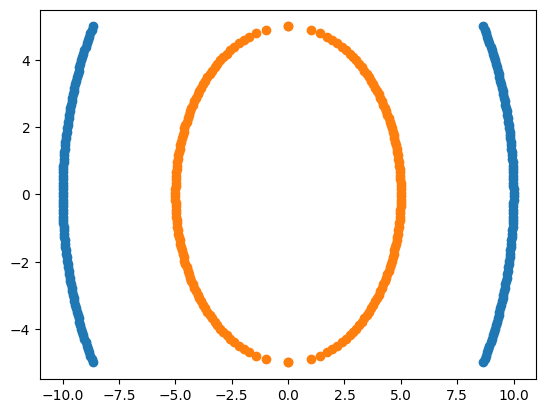

In [5]:
plt.scatter(y,x )
plt.scatter(y1,x1)

In [6]:
df1 = pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y'] = 0
df2 = pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y'] = 1
df = pd.concat([df1,df2])
df

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0
...,...,...,...
195,-1.969049,-4.59596,1
196,-1.714198,-4.69697,1
197,-1.406908,-4.79798,1
198,-0.999949,-4.89899,1


In [7]:
X = df.drop('Y',axis=1)
y = df['Y']


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# Polynomial Kernel

In [9]:
df["X1_Square"] = df["X1"]**2
df["X2_Square"] = df["X2"]**2
df["X1*X2"] = df["X1"]*df["X2"]
df

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009
...,...,...,...,...,...,...
195,-1.969049,-4.59596,1,3.877155,21.122845,9.049671
196,-1.714198,-4.69697,1,2.938476,22.061524,8.051537
197,-1.406908,-4.79798,1,1.979390,23.020610,6.750316
198,-0.999949,-4.89899,1,0.999898,24.000102,4.898740


In [10]:
X = df.drop('Y',axis=1)
y = df['Y']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X_train 

,X1,X2,X1_Square,X2_Square,X1*X2
3,8.828277,-4.696970,77.938476,22.061524,-41.466150
18,9.480297,-3.181818,89.876033,10.123967,-30.164582
2,1.406908,-4.797980,1.979390,23.020610,-6.750316
50,4.999745,0.050505,24.997449,0.002551,0.252512
74,4.344609,2.474747,18.875625,6.124375,10.751809
...,...,...,...,...,...
71,9.761334,2.171717,95.283645,4.716355,21.198857
106,-8.982945,-4.393939,80.693297,19.306703,39.470515
70,4.551063,2.070707,20.712172,4.287828,9.423918
148,-4.997704,0.151515,24.977043,0.022957,-0.757228


In [13]:
import plotly.express as px

fig = px.scatter_3d(df, x="X1", y="X2", z = "X1*X2",color="Y")
fig.show()

In [15]:
fig = px.scatter_3d(df, x="X1_Square", y="X2_Square", z = "X1*X2",color="Y")
fig.show()

In [16]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report
model = SVC(kernel="linear")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      1.00      1.00        36

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [17]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report
model = SVC(kernel="poly")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      1.00      1.00        36

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

